# Lab2 MNIST

MNIST 是一个经典的手写数字识别数据集：
- 每张图片是一个 灰度图像
- 图片大小为 28 × 28
- 标签是数字 0 ~ 9（共 10 类）

例如，一张样本可能是：
- 输入：一张手写的 “7” 的图片
- 输出：标签 7

在本实验中，我们的目标是：
训练一个模型，让它自动识别图片中的数字

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os

## 第一种方式准备数据： 下载数据集

In [4]:
def save_mnist_as_images(root='./data_mnist'):
    train_dataset = datasets.MNIST(root='./data', train=True, download=True)
    test_dataset = datasets.MNIST(root='./data', train=False, download=True)

    def save_split(dataset, split):
        for i, (img, label) in enumerate(dataset):
            folder = os.path.join(root, split, str(label))
            os.makedirs(folder, exist_ok=True)
            
            img_path = os.path.join(folder, f"{i}.png")
            img.save(img_path)

    save_split(train_dataset, 'train')
    save_split(test_dataset, 'test')

    print("✅ 已生成可视化数据集！")

save_mnist_as_images()

100.0%
100.0%
100.0%
100.0%


✅ 已生成可视化数据集！


## 第二种方式准备数据：解压数据集
（与上面二选一运行即可）

In [ ]:
def prepare_mnist_from_zip(zip_path='data_mnist.zip', root='./mnist'):
    import os
    import zipfile
    import shutil

    train_dir = os.path.join(root, 'train')
    test_dir = os.path.join(root, 'test')

    # 已存在就跳过
    if os.path.exists(train_dir) and os.path.exists(test_dir):
        print("✅ 数据已存在，跳过解压")
        return

    if not os.path.exists(zip_path):
        raise FileNotFoundError(f"❌ 找不到 {zip_path}")

    print("📦 正在解压 MNIST zip...")

    os.makedirs(root, exist_ok=True)

    # 解压
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(root)

    # 自动处理“多一层目录”的情况
    for item in os.listdir(root):
        path = os.path.join(root, item)

        if os.path.isdir(path):
            sub_train = os.path.join(path, 'train')
            sub_test = os.path.join(path, 'test')

            if os.path.exists(sub_train) and os.path.exists(sub_test):
                print("🔧 修正目录结构...")

                # 移动出来
                shutil.move(sub_train, root)
                shutil.move(sub_test, root)

                # 清理空文件夹
                try:
                    shutil.rmtree(path)
                except:
                    pass

                break

    print("✅ MNIST 准备完成（ImageFolder格式）")



# prepare_mnist_from_zip()  # 备选：若下载方式失败且本地已有 data_mnist.zip，再取消注释使用

## LeNet 模型定义

在这一部分，我们使用一个经典的卷积神经网络：LeNet 来完成手写数字识别任务。

相比前面的全连接网络（SimpleNN），LeNet 更适合处理图像数据。

在进入网络之前，MNIST 图片被处理为：(batch_size, 1, 32, 32)
- batch_size：一批样本数量
- 1：通道数（灰度图）
- 32×32：经过 Resize 后的尺寸

API说明：
nn.Conv2d(in_channels, out_channels, kernel_size)
- in_channels：输入通道数
- out_channels：输出通道数（卷积核个数）
- kernel_size：卷积核大小（如 5 表示 5×5）

In [5]:
class LeNet(torch.nn.Module):
    def __init__(self):
        super(LeNet, self).__init__()
        self.conv1 = torch.nn.Sequential(
            torch.nn.Conv2d(1, 6, kernel_size=5),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2),
        )
        self.conv2 = torch.nn.Sequential(
            # TODO 1: 定义卷积层
            # 提示：
            # - 输入通道数 = 上一层的输出通道数（conv1 输出为 6）
            # - 输出通道数 = 16
            # - 卷积核大小 = 5
            torch.nn.Conv2d(6, 16, kernel_size= 5 ),
            
            # TODO 2: 添加激活函数
            # 提示：使用 ReLU
            torch.nn.ReLU(),
            
            # TODO 3: 添加池化层
            # 提示：kernel_size=2
            torch.nn.MaxPool2d(kernel_size=2),
        )
        self.conv3 = torch.nn.Sequential(
            torch.nn.Conv2d(16, 120, kernel_size=5),
            torch.nn.ReLU(),
        )
        self.fc = torch.nn.Sequential(
            torch.nn.Linear(120, 84),
            torch.nn.Linear(84, 10),
        )

    def forward(self, x):
        batch_size = x.size(0)
        x = self.conv1(x)  # 一层卷积层,一层池化层,一层激活层(图是先卷积后激活再池化，差别不大)
        x = self.conv2(x)  # 再来一次
        x = self.conv3(x)  # 再来一次
        x = x.view(batch_size, -1)  # flatten 变成全连接网络需要的输入 (batch, 120,1,1) ==> (batch,120), -1 此处自动算出的是120
        x = self.fc(x)
        return x  # 最后输出的是维度为10的，也就是（对应数学符号的0~9）


##  三层全连接网络

设计网络一共有 3 层全连接层（Linear）：

输入层 (784) → 隐藏层1 (128) → 隐藏层2 (64) → 输出层 (10)

- 784：输入特征数（28 × 28 = 784）
- 128 / 64：隐藏层神经元数量（可以理解为特征提取能力）
- 10：输出类别数（数字 0~9）

In [6]:

# 定义一个简单的神经网络
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(784, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(-1, 784)  # 展平输入
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        return x


## 数据加载

In [7]:

# 创建数据加载器
def create_data_loaders(batch_size=64):
    
    transform = transforms.Compose([
        transforms.ToTensor(), 
        transforms.Grayscale(num_output_channels=1),
        transforms.Normalize((0.1307,), (0.3081,))
    ])

    # train_dataset = datasets.ImageFolder(
    #     root='./mnist/train',
    #     transform=transform
    # )
    train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

    # test_dataset = datasets.ImageFolder(
    #     root='./mnist/test',
    #     transform=transform
    # )

    test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

    
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    

    return train_loader, test_loader




## 训练模型

In [8]:

# 训练模型的函数
def train_model(model, train_loader, criterion, optimizer, num_epochs=10):
    losses = []
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            # TODO 1 梯度清零
            
            optimizer.zero_grad()

            # TODO 2: 前向传播
            # 提示：
            # - 输入 images 进入模型
            # - 得到预测输出 outputs
            outputs = model(images)

            # 计算损失（已给出）
            loss = criterion(outputs, labels)

            # TODO 3: 反向传播
            # 提示：
            # - 计算 loss 对参数的梯度
            # - 使用 loss.xxx()
            
            loss.backward()

            # 参数更新（已给出）
            optimizer.step()

            running_loss += loss.item()
        avg_loss = running_loss / len(train_loader)
        losses.append(avg_loss)
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")
    return losses

# 绘制损失曲线的函数
def plot_losses(losses):
    plt.plot(losses, label='Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss Over Epochs-20250321')
    plt.legend()
    plt.show()


## 测试模型

In [9]:

# 测试模型的函数
def evaluate_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = 100 * correct / total
    print(f'Accuracy of the network on the test images: {accuracy:.2f}%')
    return accuracy


## 输出测试图片

In [10]:

# 推理模型的函数，并输出测试图片
def infer_model_and_display_image(model, test_loader):
    model.eval()
    sample_input, true_label = next(iter(test_loader))  # 获取一个样本
    sample_input = sample_input[:1]  # 取第一个样本
    true_label = true_label[:1]

    with torch.no_grad():
        output = model(sample_input)
        _, predicted = torch.max(output.data, 1)

    # 显示图片和预测结果
    plt.figure(figsize=(5, 2))
    plt.subplot(1, 2, 1)
    plt.imshow(sample_input.squeeze().numpy(), cmap='gray')
    plt.title(f'True Label: {true_label.item()}')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.text(0.5, 0.5, f'Predicted Label: {predicted.item()}', fontsize=12, ha='center', va='center')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    return predicted.item()


## 主函数


Epoch [1/10], Loss: 0.2676
Epoch [2/10], Loss: 0.1122
Epoch [3/10], Loss: 0.0790
Epoch [4/10], Loss: 0.0586
Epoch [5/10], Loss: 0.0482
Epoch [6/10], Loss: 0.0376
Epoch [7/10], Loss: 0.0341
Epoch [8/10], Loss: 0.0301
Epoch [9/10], Loss: 0.0251
Epoch [10/10], Loss: 0.0214


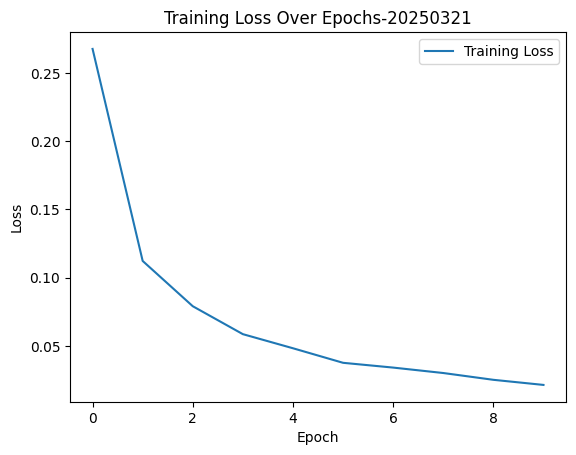

Accuracy of the network on the test images: 97.40%


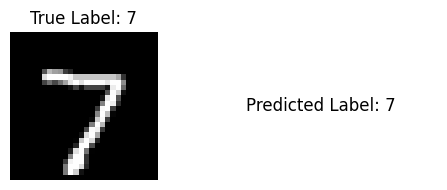

In [11]:

# 主函数，整合训练、测试和推理
def main():
    # 设置超参数
    batch_size = 64
    learning_rate = 0.001
    num_epochs = 10

    # 创建数据加载器
    train_loader, test_loader = create_data_loaders(batch_size=batch_size)

    # 初始化模型、损失函数和优化器
    # TODO: 选择一个模型
    # 提示： model = SimpleNN() or model = LeNet()
    model = SimpleNN()

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # 训练模型
    losses = train_model(model, train_loader, criterion, optimizer, num_epochs=num_epochs)

    # 绘制损失曲线
    plot_losses(losses)

    # 测试模型
    accuracy = evaluate_model(model, test_loader)

    # 推理模型并显示图片
    prediction = infer_model_and_display_image(model, test_loader)

if __name__ == "__main__":
    main()
